# Postprocess Mixing & Weighted Plots


This notebook loads postprocessed CMS Flow Matching outputs, computes HS/MB mixing
weights, builds a weighted synthetic sample, and reproduces the event/jet/particle
histograms produced in the original `plot_postprocess.ipynb`.

Steps:
1. Point the configuration block to the postprocessed ROOT files you want to analyse.
2. Run the helper cells to load each dataset, compute weights, and build the weighted mix.
3. Execute the plotting cells to compare the components, the weighted mix, and (optionally) a validation sample.


In [56]:

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [57]:


from parnassus_core.experiments.cms_2011.performance.performance import (
    CMS2011Performance,
    CMS2011PlotHelper,
    CMS2011Sample,
    CMS2011PerformanceConfig,
)


from parnassus_core.performance.config import Source


In [58]:
config_dict = {
    "samples": {
        "zqqb": [
            {
                "name": "parnassus",
                "path": "ZtoQQB_postprocess_9k_test_eta30Eval.root",
                "pflow_type": "fm",
                "label": "Parnassus (FM)",
            },
        ]
    }
}


In [59]:


config = CMS2011PerformanceConfig.from_dict(config_dict)



In [60]:


perf = CMS2011Performance(config)



In [61]:


config.sample_dict.keys()



dict_keys([<CMS2011Sample.ZQQB: 'ttbar'>])

In [62]:


perf.load()



Loading data for parnassus from ZtoQQB_postprocess_9k_test_eta30Eval.root


In [63]:



perf.sample_data_dict[CMS2011Sample.ZQQB].filter_events()



Filtering events for PF with source Source.PF
Data(name=PF, source=Source.PF), events filtered: 9977
Filtering events for TR with source Source.TR
Data(name=TR, source=Source.TR), events filtered: 9977
Filtering events for parnassus with source Source.FM
Data(name=parnassus, source=Source.FM), events filtered: 9977


In [64]:


perf.sample_data_dict[CMS2011Sample.ZQQB].data_dict["PF"]["particle/jet/pt"]



array([array([13.15435696,  2.78306484,  1.68634677,  1.08274889,  1.47191739,
               8.7946701 ,  5.85013056,  3.92025948,  4.59220123,  1.99286973,
              11.24955273,  2.12006235,  5.12426138,  1.89780116,  1.37677312,
               4.02995491, 22.19750977])                                      ,
       array([ 7.28326368,  1.27925134, 10.16260719,  5.8883462 ,  3.92282867,
               2.69553661,  1.32958829,  1.60619056,  1.50712574,  1.92522466,
               3.90627527,  1.78722274,  3.03340626,  1.80125654])            ,
       array([ 4.69931507,  8.63519478,  4.19995403, 22.15878105,  2.79339933,
               2.17353773,  2.64604449,  2.40602994,  1.02986062,  6.26337385,
               8.54938316,  5.10401011,  3.95030379,  2.09272695,  1.19593477,
               1.08602953,  1.63037562,  2.53376603,  1.11092389,  1.31882524]),
       ...,
       array([ 4.29295921, 12.68138695,  3.01048899,  4.45227623,  2.0812366 ,
               1.09622812,  2.813998

In [65]:

perf.sample_data_dict[CMS2011Sample.ZQQB].data_dict["PF"].particle_data_jet["pt"][1310]


array([ 8.4565134 ,  2.85412216,  2.02370286,  1.55880892,  1.02270424,
        1.93980849,  2.71823835,  1.72727096,  1.44391727, 14.98113251,
        1.56430721])

In [66]:
perf.sample_data_dict[CMS2011Sample.ZQQB].process_data()


Calculating event data for PF with source Source.PF
Calculating event data for TR with source Source.TR
Calculating event data for parnassus with source Source.FM
Processing data for PF with source Source.PF
Calculating event residuals for PF with source Source.PF against TR with source Source.TR
Matching jets for PF with source Source.PF against TR with source Source.TR


Matching jets: 100%|██████████| 9977/9977 [00:01<00:00, 8266.84it/s]


Calculating jet residuals for PF with source Source.PF against TR with source Source.TR


residuals: 100%|██████████| 9977/9977 [00:00<00:00, 48246.69it/s]


Calculating particle residuals for PF with source Source.PF against TR with source Source.TR
Split:  all


...

Split:  jet


residuals: 100%|██████████| 9977/9977 [00:00<00:00, 30626.16it/s]


Split:  bkg


residuals: 100%|██████████| 9977/9977 [00:00<00:00, 24543.93it/s]

Calculating impact parameters for parnassus with source Source.FM
No impact parameters found in parnassus for split all. Skipping.
No impact parameters found in parnassus for split jet. Skipping.
No impact parameters found in parnassus for split bkg. Skipping.
Processed data for sample ZQQB


In [67]:



perf.process()




Processing sample: ZQQB
Skipping filter_events: events already filtered
Skipping calculate_event_data: event data already calculated
Skipping calculate_event_data: event data already calculated
Skipping calculate_event_data: event data already calculated
Processing data for PF with source Source.PF
Skipping calculate_event_residuals: event residuals already calculated
Skipping match_jets: jets already matched
Skipping calculate_jet_residuals: jet residuals already calculated
Skipping calculate_particle_residuals: particle residuals already calculated
Skipping calculate_impact_parameters: impact parameters already calculated
Processing data for parnassus with source Source.FM
Skipping calculate_event_residuals: event residuals already calculated
Skipping match_jets: jets already matched
Skipping calculate_jet_residuals: jet residuals already calculated
Skipping calculate_particle_residuals: particle residuals already calculated
Skipping calculate_impact_parameters: impact parameters alr

In [68]:

from parnassus_core.performance import labels as perf_labels
style_dict = {
    "PF": {
        "linewidth": 2,
        "color": "#1f77b4",
        "alpha": 0.3,
    },
    "TR": {
        "linewidth": 2,
        "color": "black",
        "alpha": 1,
    },
    "parnassus": {
        "linewidth": 2,
        "color": "crimson",
    },
}

perf_labels.SAMPLE_LABELS["ttbar"] = r"$Z\to q\bar{q}$"   # optional rename
perf_labels.SAMPLE_LABELS["zqqb"] = r"$Z\to q\bar{q}$"   # required for new enum


In [69]:
from parnassus_core.performance import labels as perf_labels
perf_labels.VAR_LABELS.setdefault("m_vis", r"$M_{\mathrm{vis}}$")
perf_labels.VAR_LABELS.setdefault("thrust", r"$T$")
perf_labels.RESIDUAL_VAR_LABELS.setdefault("m_vis_res", r"$M_{\mathrm{vis}}^{\mathrm{reco}} - M_{\mathrm{vis}}^{\mathrm{truth}}$")
perf_labels.RESIDUAL_VAR_LABELS.setdefault("thrust_res", r"$T^{\mathrm{reco}} - T^{\mathrm{truth}}$")


'$T^{\\mathrm{reco}} - T^{\\mathrm{truth}}$'

In [70]:


plot_helper = CMS2011PlotHelper(
    perf, plot_truth=False, style_dict=style_dict, font_size=25
)



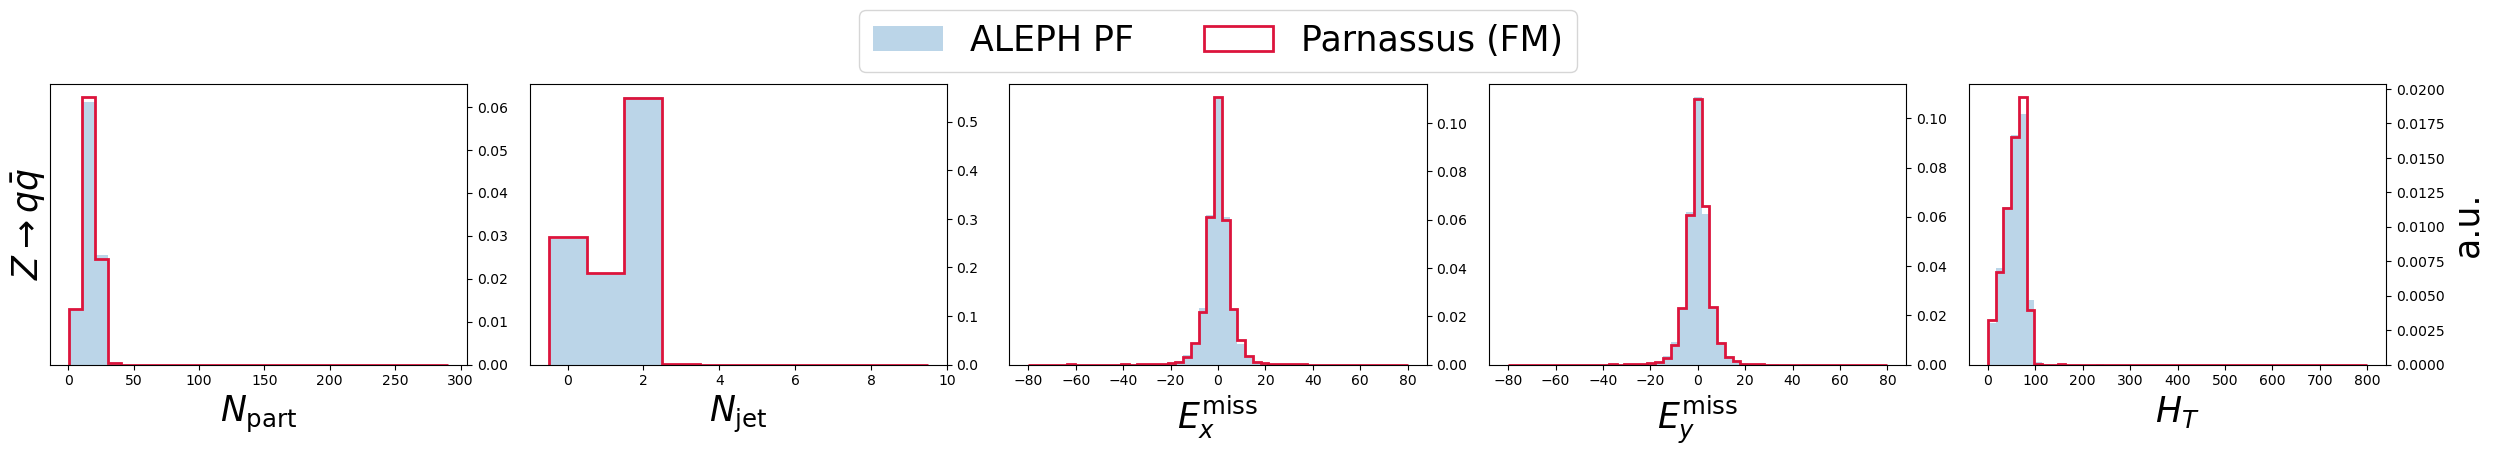

In [71]:


fig = plot_helper.plot_event_features(residuals=False)



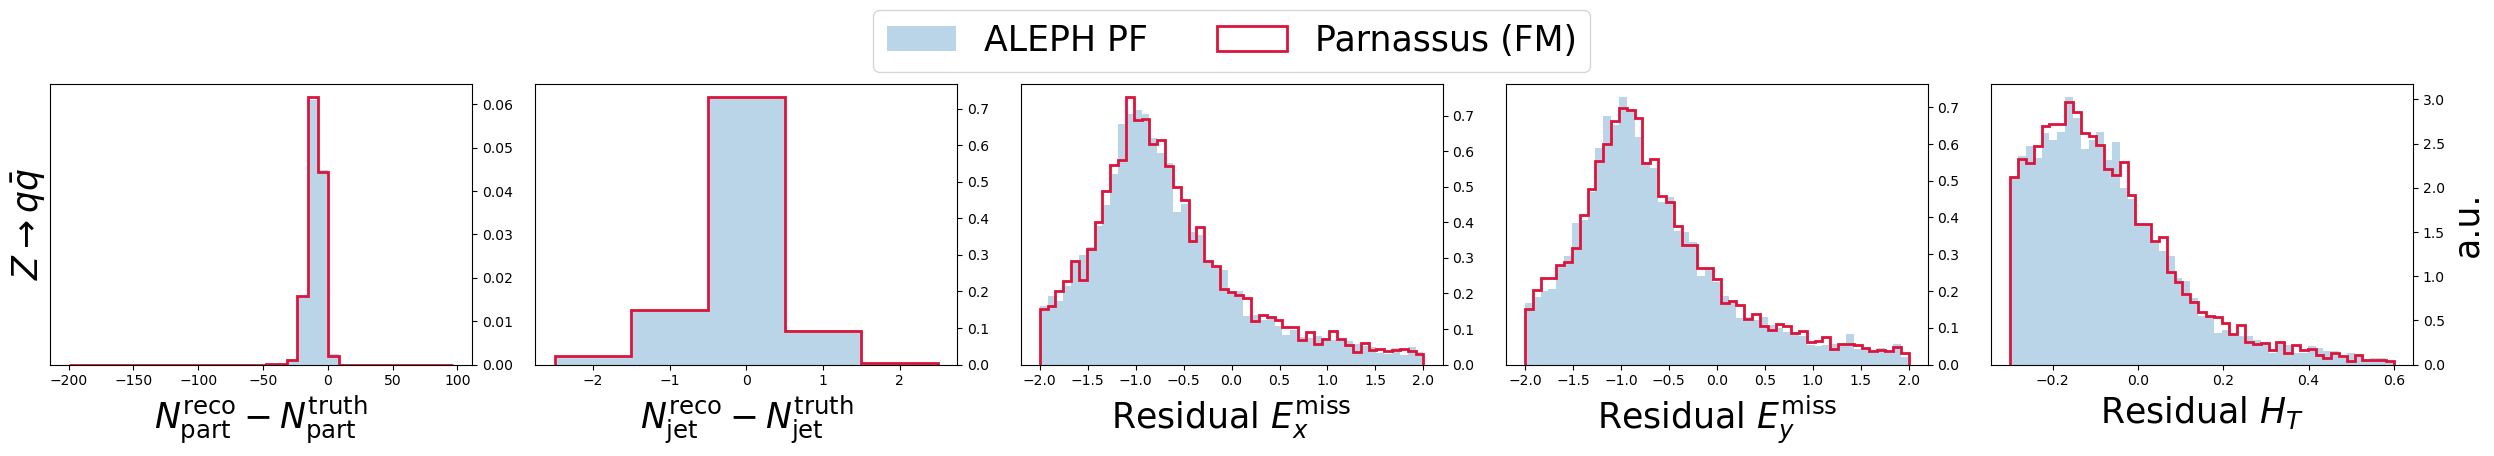

In [72]:


fig = plot_helper.plot_event_features(residuals=True)


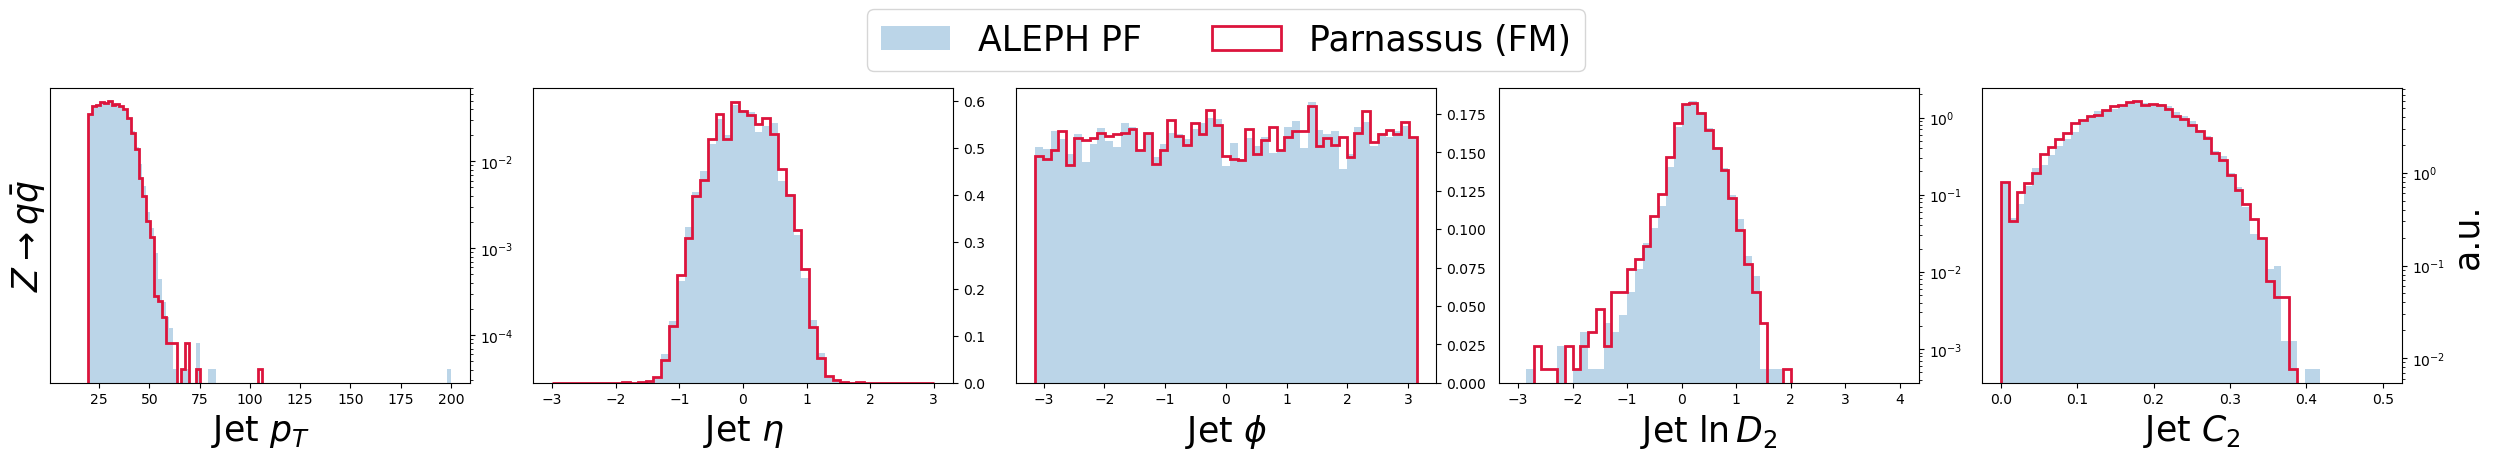

In [73]:
fig = plot_helper.plot_jet_features(log_scale_vars=["pt", "d2", "c2"])

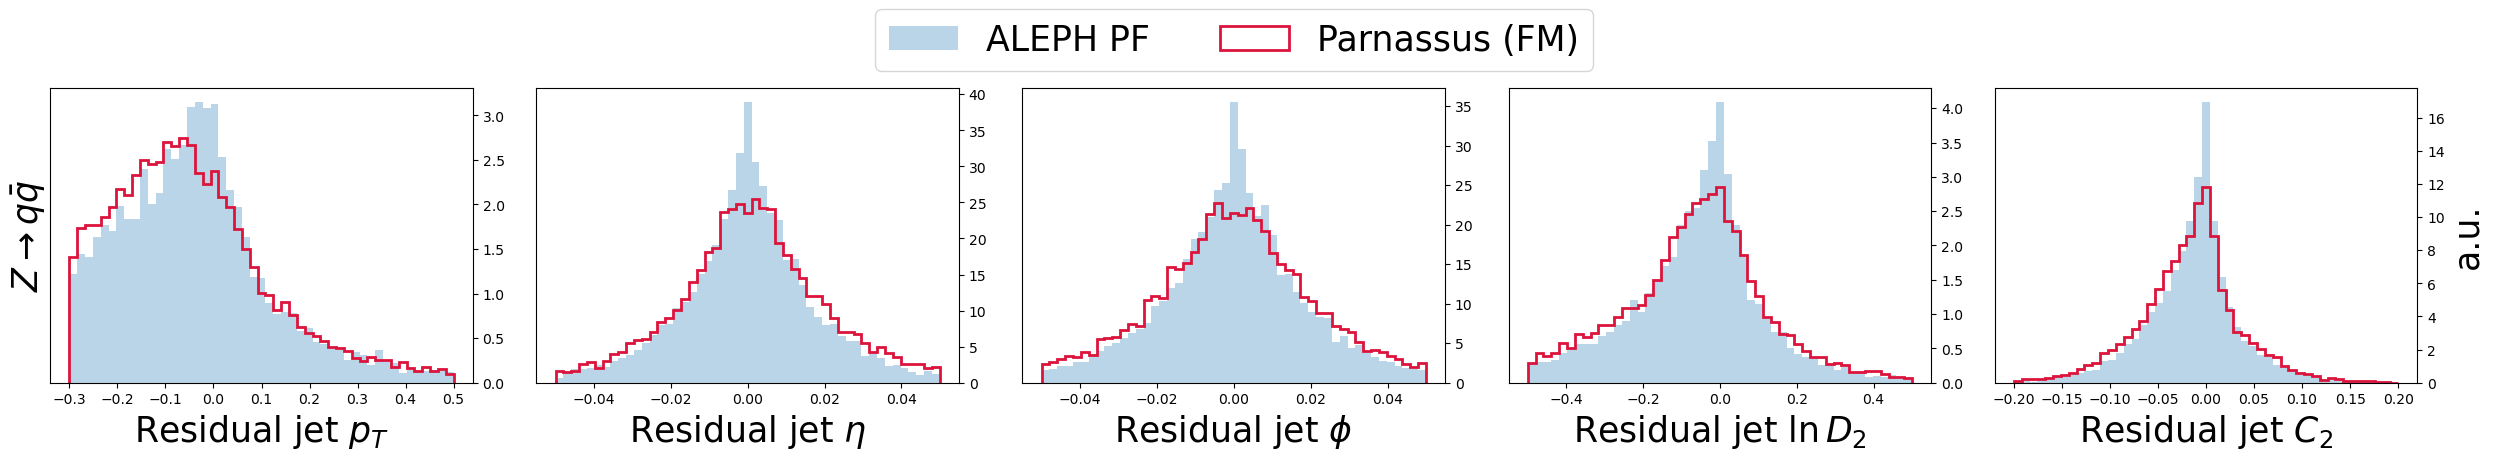

In [74]:


fig = plot_helper.plot_jet_features(residuals=True)



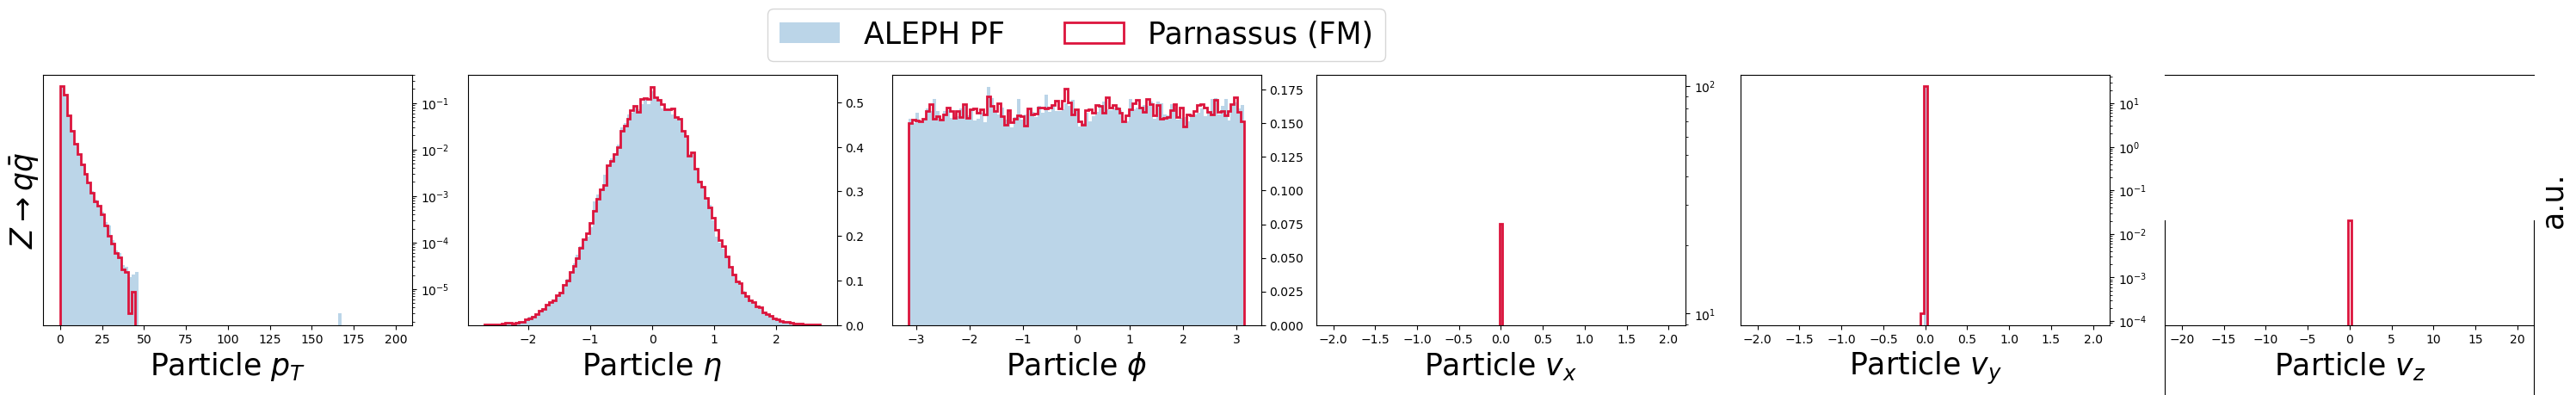

In [75]:
fig = plot_helper.plot_particle_features(log_scale_vars=["pt", "vx", "vy", "vz"])

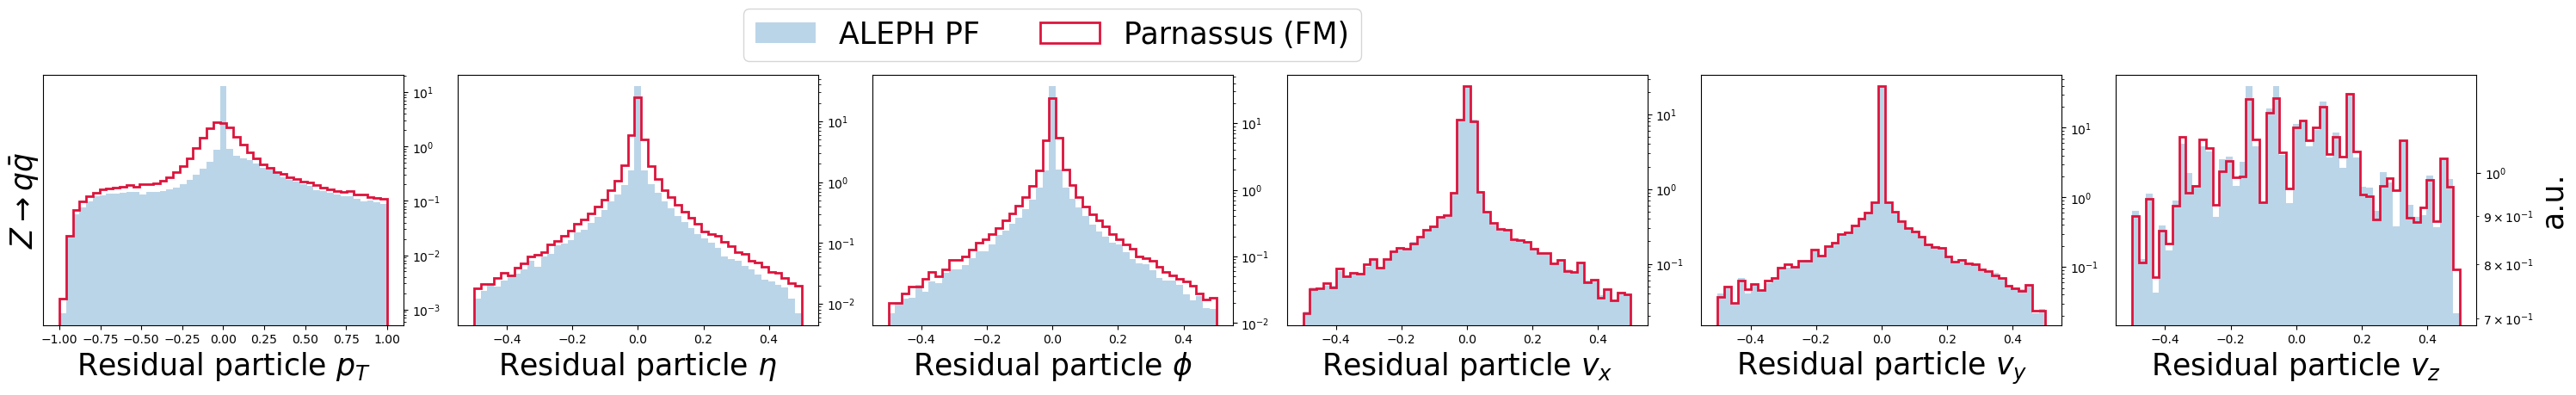

In [76]:


fig = plot_helper.plot_particle_features(residuals=True, log_scale_vars="all")



In [78]:
import numpy as np

def _compute_mass_thrust_from_particles(particle_dict):
    masses, thrusts = [], []
    for pt, eta, phi in zip(particle_dict["pt"], particle_dict["eta"], particle_dict["phi"]):
        pt = np.asarray(pt)
        if pt.size == 0:
            masses.append(0.0)
            thrusts.append(0.0)
            continue
        eta = np.asarray(eta)
        phi = np.asarray(phi)
        px = pt * np.cos(phi)
        py = pt * np.sin(phi)
        pz = pt * np.sinh(eta)
        energy = np.sqrt(px**2 + py**2 + pz**2)
        px_sum, py_sum, pz_sum = px.sum(), py.sum(), pz.sum()
        e_sum = energy.sum()
        mass_sq = max(e_sum**2 - (px_sum**2 + py_sum**2 + pz_sum**2), 0.0)
        masses.append(np.sqrt(mass_sq))
        momenta = np.stack([px, py, pz], axis=1)
        norms = np.linalg.norm(momenta, axis=1)
        denom = norms.sum()
        if denom <= 0:
            thrusts.append(0.0)
            continue
        axis = momenta[np.argmax(norms)] / (norms.max() + 1e-12)
        for _ in range(50):
            dots = momenta @ axis
            signs = np.where(dots >= 0, 1.0, -1.0)
            axis_new = (momenta * signs[:, None]).sum(axis=0)
            norm = np.linalg.norm(axis_new)
            if norm <= 1e-12:
                break
            axis_new /= norm
            if np.linalg.norm(axis_new - axis) < 1e-6:
                axis = axis_new
                break
            axis = axis_new
        thrusts.append(np.abs(momenta @ axis).sum() / denom)
    return np.asarray(masses, dtype=np.float32), np.asarray(thrusts, dtype=np.float32)

sample = perf.sample_data_dict[CMS2011Sample.ZQQB]
for data in sample.data_dict.values():
    mass_arr, thrust_arr = _compute_mass_thrust_from_particles(data.particle_data_all)
    data.event_data["m_vis"] = mass_arr
    data.event_data["thrust"] = thrust_arr

truth_mass = sample.data_dict["TR"].event_data["m_vis"]
truth_thrust = sample.data_dict["TR"].event_data["thrust"]
for data in sample.data_dict.values():
    if data.source.name == "TR":
        data.event_data["m_vis_res"] = np.zeros_like(truth_mass)
        data.event_data["thrust_res"] = np.zeros_like(truth_thrust)
    else:
        data.event_data["m_vis_res"] = data.event_data["m_vis"] - truth_mass
        data.event_data["thrust_res"] = data.event_data["thrust"] - truth_thrust


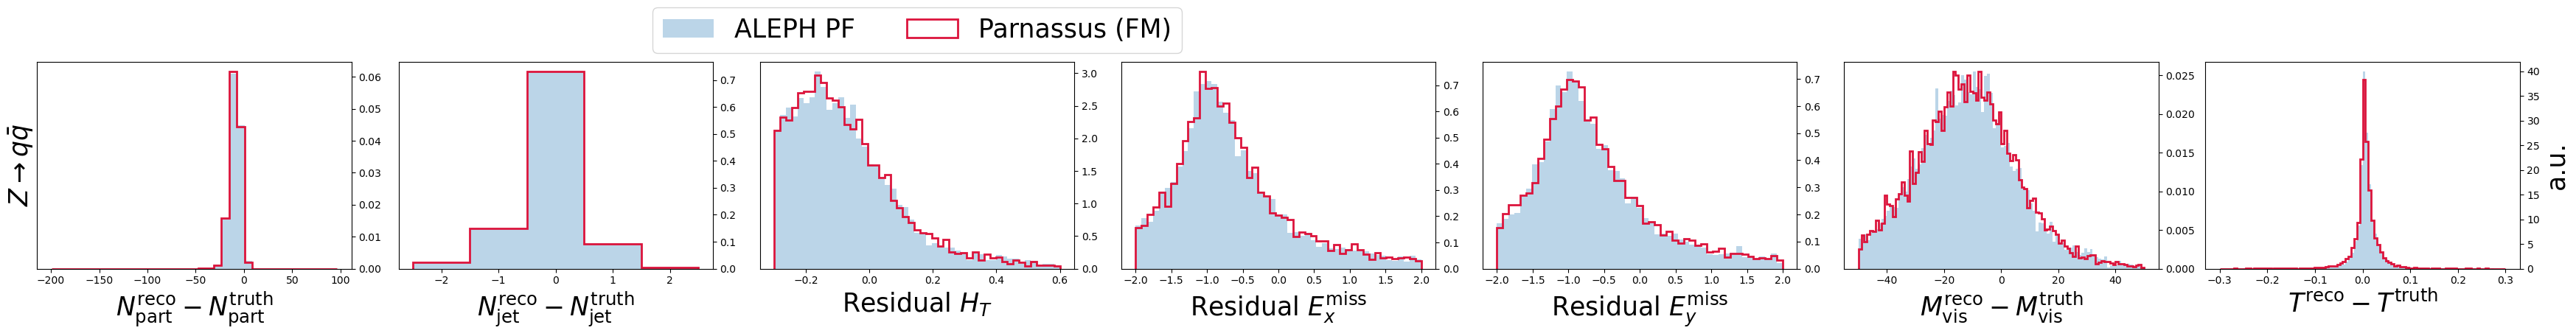

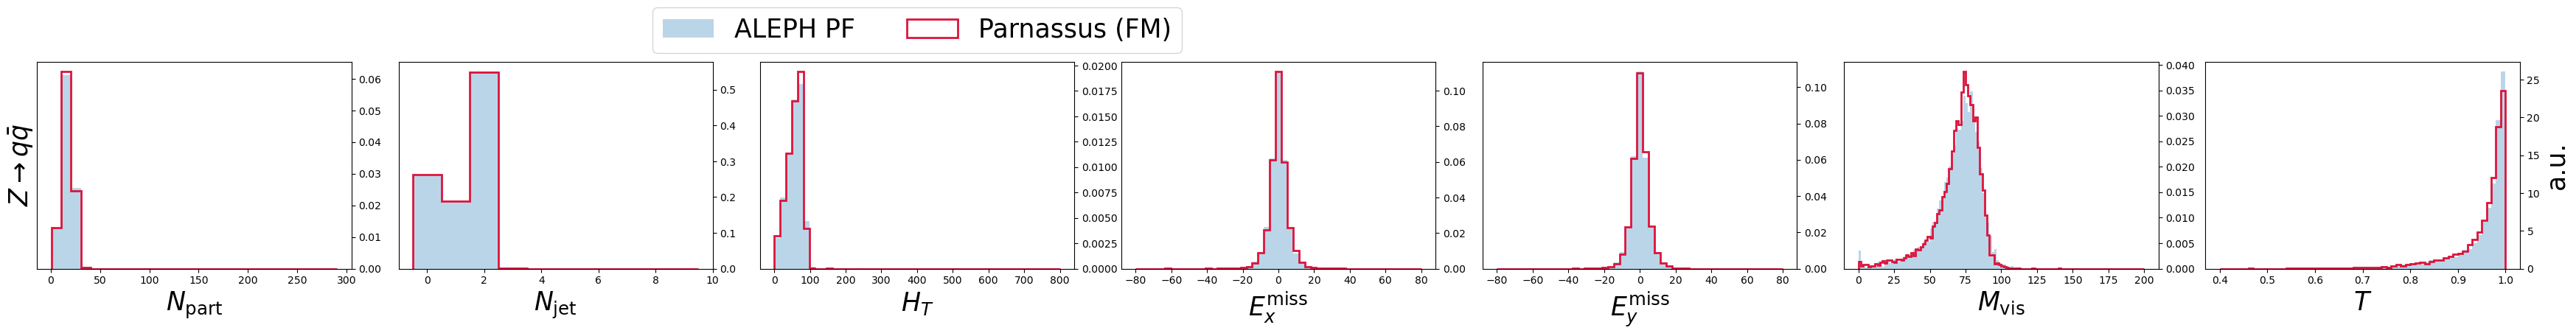

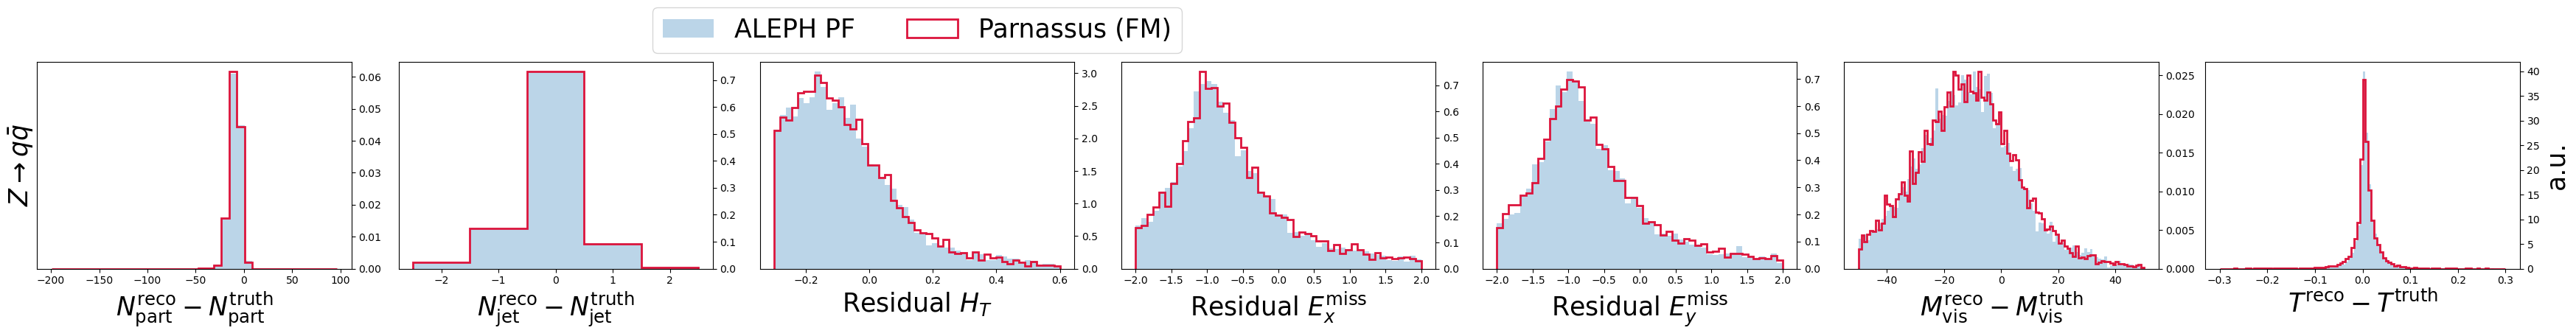

In [79]:
event_bins = plot_helper.bins_config.event_bins
event_bins.setdefault("m_vis", {})[CMS2011Sample.ZQQB] = np.linspace(0, 200, 121)
event_bins.setdefault("thrust", {})[CMS2011Sample.ZQQB] = np.linspace(0.4, 1.0, 61)

event_res_bins = plot_helper.bins_config.event_res_bins
event_res_bins.setdefault("m_vis_res", {})[CMS2011Sample.ZQQB] = np.linspace(-50, 50, 101)
event_res_bins.setdefault("thrust_res", {})[CMS2011Sample.ZQQB] = np.linspace(-0.3, 0.3, 101)

aleph_event_vars = ["npart", "njet", "ht", "met_x", "met_y", "m_vis", "thrust"]
fig = plot_helper.plot_features("event_data", aleph_event_vars, bins=event_bins)
fig

aleph_event_res_vars = [f"{var}_res" for var in aleph_event_vars]
fig = plot_helper.plot_features("event_data", aleph_event_res_vars, bins=event_res_bins)
fig
